In [1]:
import sys
sys.path.append('../')
from utils_models import *
from scipy.optimize import minimize


In [5]:

with open('../pickles/12_mesolve_computational.pkl', 'rb') as file:
    results_compu_1em3 = pickle.load(file)


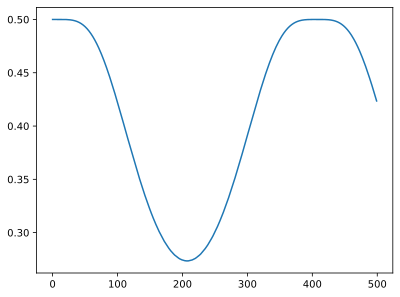

In [6]:
plt.plot([ abs(state[1,0]) for state in results_compu_1em3[2].states_dressed_to_2_level_dm])

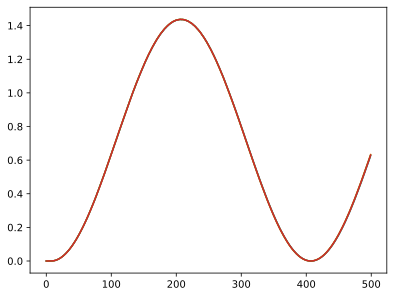

In [7]:
for result in results_compu_1em3:
    plt.plot(result.expect[1])

In [10]:
max_ql = 20
max_ol = 50
system = FluxoniumOscillatorSystem(
    computaional_states = '1,2',
        EJ = 2.65,
        EC = 0.6,
        EL = 0.13,
        Er = 7.17391479,
        g_strength = 0.13,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in [1,2] for ol in range(30) ],
)


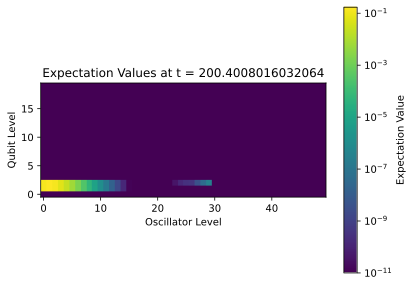

In [13]:
result = results_compu_1em3[2]
time_index = 200
qubit_levels = 20
oscillator_levels = 50
product_to_dressed = system.product_to_dressed

if hasattr(result, 'states'):
    dm = result.states[time_index]
elif hasattr(result, 'y'):
    dm = result.y[time_index]
if hasattr(result, 'states_pad_back_custom'):
    dm = result.states_pad_back_custom[time_index]
if dm.shape[1] == 1:
    dm = qutip.ket2dm(dm)
dm = qutip.Qobj(dm.full())
dm = 0.5 * (dm + dm.dag())
dm = dm / dm.tr()

# dm = pad_back_function(dm)
grid = np.zeros(( qubit_levels,oscillator_levels))

for qubit_level in range(qubit_levels):
    for oscillator_level in range(oscillator_levels):
        product_state = (qubit_level, oscillator_level)
        dressed_state = product_to_dressed[product_state]
        if dressed_state < dm.dims[0][0]:
            # Create a basis state corresponding to the dressed state
            basis_state = qutip.basis(dm.dims[0][0], dressed_state)
            # Calculate the expectation value
            expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
        else:
            expectation_value = 0
        grid[ qubit_level,oscillator_level] = expectation_value
grid[grid < 1e-11] = 1e-11
plt.imshow(grid, cmap='viridis', origin='lower', norm=LogNorm())
plt.colorbar(label='Expectation Value')
plt.xlabel('Oscillator Level')
plt.ylabel('Qubit Level')
plt.title(f'Expectation Values at t = {result.times[time_index]}')
plt.show()

In [14]:
subsystem_dims = [max(indexes) + 1 for indexes in zip(*system.product_to_dressed.keys())]
# Precompute indices as before
prod_dims_cumprod = np.cumprod(subsystem_dims[::-1])[::-1]
prod_dims_cumprod_shifted = np.roll(prod_dims_cumprod, shift=-1)
prod_dims_cumprod_shifted[-1] = 1

# Assuming product_to_dressed keys are tuples like (ql, ol), compute the index for each product state
indices_map = {pstate: sum(np.array(pstate) * prod_dims_cumprod_shifted) for pstate in system.product_to_dressed.keys()}


def convert_to_product(dm):
    if dm.isket:
        dm = qutip.ket2dm(dm)
    dressed_dm_data = dm.full()
    rho_product = np.zeros((np.prod(subsystem_dims), np.prod(subsystem_dims)), dtype=complex)

    # Now, instead of iterating and unpacking, directly use the dressed indices
    for product_state, dressed_index1 in system.product_to_dressed.items():
        index1 = indices_map[product_state]  # Use precomputed index
        for product_state2, dressed_index2 in system.product_to_dressed.items():
            index2 = indices_map[product_state2]  # Use precomputed index
            # Extract element directly without unpacking
            element = dressed_dm_data[dressed_index1, dressed_index2]
            rho_product[index1, index2] += element

    rho_product = qutip.Qobj(rho_product, dims=[subsystem_dims, subsystem_dims])
    return rho_product

def truncate_first_subsystem(rho):
    dim_1 = rho.dims[0][0]
    dim_2  =  rho.dims[0][1]
    rho_array = rho.full()
    rho_reshaped = rho_array.reshape((dim_1, dim_2, dim_1, dim_2))
    truncated_rho_reshaped = rho_reshaped[1:3, :, 1:3, :]
    truncated_rho_array = truncated_rho_reshaped.reshape((2 * dim_2, 2 * dim_2))
    truncated_rho = qutip.Qobj(truncated_rho_array, dims=[[2, dim_2], [2, dim_2]])
    return truncated_rho



def truncate_second_subsystem(rho,n):
    dim_1 = rho.dims[0][0]
    dim_2  =  rho.dims[0][1]
    if n >= dim_2:
        raise ValueError("n is out of bounds for the dimensionality of the second subsystem.")
    rho_array = rho.full()
    rho_reshaped = rho_array.reshape((dim_1, dim_2, dim_1, dim_2))
    truncated_rho_reshaped = rho_reshaped[:, n:n+1, :, n:n+1]
    # Reshape back to 2D array
    truncated_rho_array = truncated_rho_reshaped.reshape((dim_1, dim_1))
    # Create a new Qobj from the truncated array, adjusting the dimensions list to reflect the truncation
    truncated_rho = qutip.Qobj(truncated_rho_array, dims=[[dim_1], [dim_1]])
    return truncated_rho


500.0

# Attemp 2: population-normalized sum of fidelity with different phase for different levels

In [16]:

class WeightedInfidelityCalculatorV2:
    def __init__(self):
        self.cache = {}

    def _cache_key(self, rho):
        return (id(rho))

    def _compute_pre_cached_values(self, rho):
        key = self._cache_key(rho)
        if key not in self.cache:
            rho_array = rho.full().reshape((rho.dims[0][0], rho.dims[0][1], rho.dims[0][0], rho.dims[0][1]))
            weights = np.real(np.diag(np.trace(rho_array, axis1=0, axis2=2)))
            dim_1, dim_2  = rho.dims[0]
            self.cache[key] = (rho_array,weights,dim_1,dim_2)
        return self.cache[key]

    def calc_weighted_infidelity_with_phase(self, theta, rho, state_ideal):
        rho_array,weights, dim_1, dim_2 = self._compute_pre_cached_values(rho)
        
        fid_sum = 0.0
        for ol in range(len(theta)):
            gate = qutip.Qobj(np.array([[1, 0], [0, np.exp(1.0j * theta[ol])]]))
            A = qutip.ket2dm(gate*state_ideal)
            sqrtmA = A.sqrtm()
            B = qutip.Qobj(rho_array[:, ol, :, ol].reshape((dim_1, dim_1)), dims=[[dim_1], [dim_1]])/ weights[ol]
            eig_vals = (sqrtmA * B * sqrtmA).eigenenergies()
            fid = float(np.real(np.sqrt(eig_vals[eig_vals > 0]).sum()))
            fid_sum += fid * weights[ol]
        return 1 - fid_sum
    
    def calc_infidelity_with_phase_for_single_osc_lvl(self, theta,osc_lvl, rho, state_ideal):
        rho_array,weights, dim_1, dim_2 = self._compute_pre_cached_values(rho)
        fid_sum = 0.0
        for ol in [osc_lvl]:
            gate = qutip.Qobj(np.array([[1, 0], [0, np.exp(1.0j * theta[0])]]))
            A = qutip.ket2dm(gate*state_ideal)
            sqrtmA = A.sqrtm()
            B = qutip.Qobj(rho_array[:, ol, :, ol].reshape((dim_1, dim_1)), dims=[[dim_1], [dim_1]])/ weights[ol]
            eig_vals = (sqrtmA * B * sqrtmA).eigenenergies()
            fid = float(np.real(np.sqrt(eig_vals[eig_vals > 0]).sum()))
            fid_sum += fid * weights[ol]
        return 1 - fid_sum
    

tot_time = results_compu_1em3[0].times[-1]
tlist = np.linspace(0, tot_time, int(tot_time))
slice_interval = 20
new_tlist = tlist[::slice_interval]
num_time_steps = len(new_tlist)


zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [
                zero,
                one,
                (zero +  one).unit(),
                (zero - 1j * one).unit(),
                ]


# infidelity1 = []
phase1 = [[] for _ in range(5)]
for idx in tqdm(range(num_time_steps)):
    calculator = WeightedInfidelityCalculatorV2()
    dms = [result.states_pad_back_custom[idx*slice_interval] for result in results_compu_1em3]
    dms_two_lvl = [truncate_first_subsystem(convert_to_product(dm)) for dm in dms]
    for ol in range(5):
        def objective_function(x):
            infidelities = [calculator.calc_infidelity_with_phase_for_single_osc_lvl(x,
                                                                ol,
                                                                dm_two_lvl,
                                                                state_ideal)  for dm_two_lvl, state_ideal in zip(dms_two_lvl,states_ideal)]
            mean = np.mean(infidelities)
            return mean
        x0 = [0.0]
        bounds = [(0, 2 * 3.141592653589793)]
        opt_result = minimize(objective_function, x0,method="COBYLA")
        # infidelity1.append(opt_result.fun)
        phase1[ol].append(opt_result.x[0])


100%|██████████| 25/25 [00:39<00:00,  1.57s/it]ow/lib/python3.10/site-packages/scipy/sparse/_base.py: 653


In [91]:

# with open('../pickles/optimize_ol_phases_new_op_EJ262.pkl', 'wb') as file:
#     pickle.dump(phase1, file)

In [92]:
# with open('../pickles/optimize_ol_phases_new_op_EJ262.pkl', 'rb') as file:
#     phase1 =  pickle.load( file)

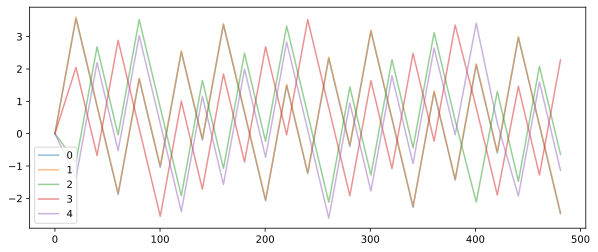

In [17]:
plt.figure(figsize=(10,4))

phase_list = np.array(phase1)
for i in range(5):
    plt.plot(new_tlist,phase_list[i],label = rf'{i}',alpha=0.5)
plt.legend()

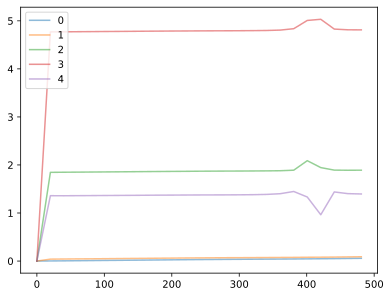

In [18]:
evals = system.qbt.eigenvals()
omega =  -1 *(evals[2]-evals[1])*2*np.pi
for i in range(5):
    resid = (np.array(phase_list[i]) - np.array(omega*new_tlist))%(2*np.pi)
    plt.plot(new_tlist,resid,label=f"{i}",alpha=0.5)
# plt.ylim(0,0.1)
plt.legend()

100%|██████████| 500/500 [00:13<00:00, 36.34it/s]


Text(0.5, 0, 'ns')

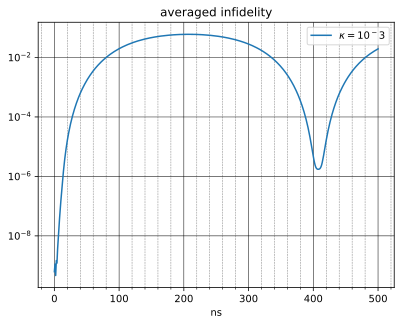

In [19]:
num_time_steps = len(results_compu_1em3[0].times)
tlist = results_compu_1em3[0].times


zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - 1j * one).unit(),
                ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(new_dm, dm_ideal))
        # fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize

infidelity1 = []
phase_lump = []
for idx in tqdm(range(num_time_steps)):
    dms = [result.states_dressed_to_2_level_dm[idx] for result in results_compu_1em3[:4]]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity1.append(opt_result.fun)
    phase_lump.append(opt_result.x[0])


plt.plot(tlist,infidelity1,label = rf'$\kappa = 10^{-3}$')

plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.legend()

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

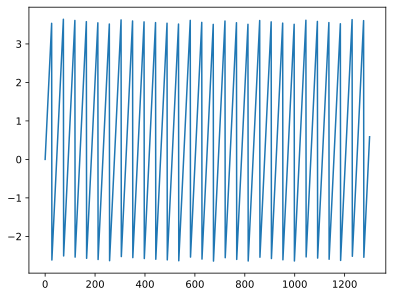

In [98]:
plt.plot(tlist,phase_lump)

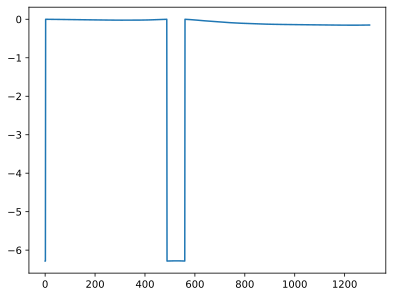

In [99]:
evals = system.qbt.eigenvals()
omega = (evals[2]-evals[1])*2*np.pi
resid = (np.array(phase_lump) - np.array(omega*tlist))%(2*np.pi) - 2*np.pi

plt.plot(tlist,resid)

Processing through tlist: 100%|██████████| 1200/1200 [00:03<00:00, 396.80it/s]
 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/matplotlib/cbook/__init__.py: 1335

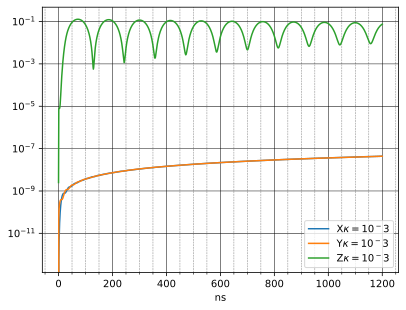

In [16]:
# colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
# linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
times = tlist

pauli_results = [results_compu_1em3[0],results_compu_1em3[1],results_compu_1em3[-2],results_compu_1em3[-1]] 
phase = phase_lump
prefix= rf'$\kappa = 10^{-3}$'

errors = {
    'X': [],
    'Y': [],
    'Z': []
}
inner_product_vals_dict = {
    'X': [],
    'Y': [],
    'Z': []
}

Paulis = [qutip.sigmax(),qutip.sigmay(),qutip.sigmaz()]


dms_ideal = [
    zero * zero.dag(),
    one * one.dag(),
    zero * one.dag(),
    one * zero.dag()
]
for idx in tqdm(range(len(times)), desc='Processing through tlist'):
    dms = [pauli_results[0].states_dressed_to_2_level_dm[idx],
        pauli_results[1].states_dressed_to_2_level_dm[idx],
        pauli_results[2].states_dressed_to_2_level_dm[idx],
        pauli_results[3].states_dressed_to_2_level_dm[idx]]
    gate = qutip.qip.operations.phasegate(theta=  phase[idx])
    for P, Pauli in zip(['X','Y','Z'],Paulis):
        inner_product_vals = []
        for dm_ideal, dm in zip(
            dms_ideal,
            [dms[0],dms[1],dms[2],dms[3]]
            ):
            the_second_term = Pauli * dm_ideal * Pauli.dag()                    
            dm = gate * dm * gate.dag()
            inner_product = (the_second_term * dm.dag()).tr()
            inner_product_vals.append(inner_product)
        errors[P].append(sum(inner_product_vals)/len(inner_product_vals))
        inner_product_vals_dict[P].append(inner_product_vals)

plt.plot(times,errors['X'],label = 'X' + prefix)
plt.plot(times,errors['Y'],label = 'Y' + prefix)
plt.plot(times,errors['Z'],label = 'Z' + prefix)


plt.xlabel("ns")
plt.yscale('log')

plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.legend()


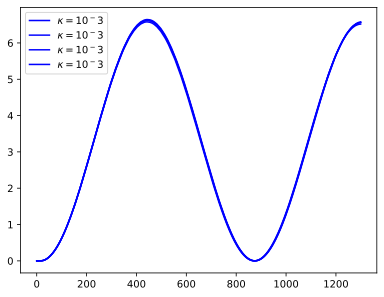

In [139]:
for computational_results, prefix, color in zip(
    [results_compu_1em3[:4]],
    [rf'$\kappa = 10^{-3}$'],
    ['blue']
    ):
    for result in computational_results:
        plt.plot(result.expect[1],color = color,label = prefix)
plt.legend()

    

# Leakage state

In [100]:

with open('../pickles/12_mesolve_leakage.pkl', 'rb') as file:
    results_leak = pickle.load(file)


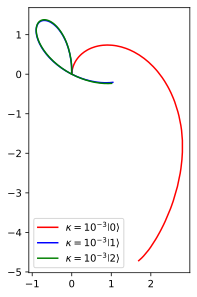

In [101]:

tot_time = 1300
tlist = np.linspace(0, tot_time, tot_time)

prefix = rf'$\kappa = 10^{{-3}}$'
first_dominant_freq =find_dominant_frequency(results_compu_1em3[0].expect[0],tlist)
colors = ['red','blue','green']
for i, result in enumerate([results_leak[0], results_compu_1em3[0], results_compu_1em3[1] ]):
    alpha = result.expect[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    plt.plot(alpha.imag,alpha.real,color=colors[i],label = prefix + rf'$\left|{i}\right>$')
plt.legend()
plt.gca().set_aspect('equal', 'box')

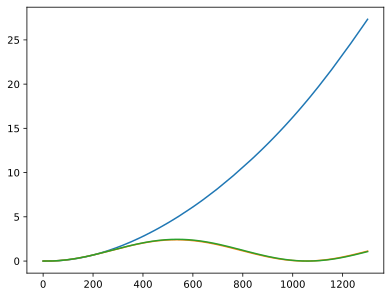

In [102]:
for i, result in enumerate([results_leak[0], results_compu_1em3[0], results_compu_1em3[1] ]):
    plt.plot(result.times, result.expect[1])

 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_67836/3125730884.py: 21

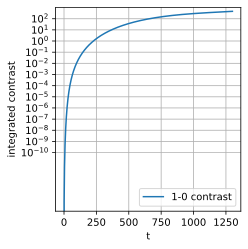

In [103]:
first_dominant_freq =find_dominant_frequency(results_leak[0].expect[-2],tlist)

plt.figure(figsize=(3+3/8,3+3/8))
kappa_val = 1e-3

alpha0 = results_leak[0].expect[-2]         *np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
alpha1 = results_compu_1em3[0].expect[-2]   *np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
alpha2 = results_compu_1em3[1].expect[-2]   *np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)

squared_diff = np.square(abs(alpha0-alpha1))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='1-0 contrast')

plt.legend(loc='lower right')
plt.yscale('log')
plt.ylim(0,1e3)
plt.yticks([1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,1e1,1e2])
# plt.xlim(0,tot_time)
plt.grid()
plt.tight_layout()
plt.xlabel('t')
plt.ylabel('integrated contrast')
# plt.savefig("fig06_integral.pdf", format='pdf', bbox_inches='tight')
plt.show()



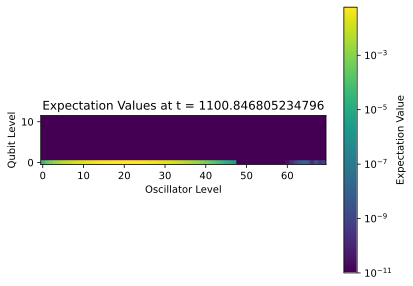

In [105]:
result = results_leak[0]

max_ql = 12
max_ol = 70


time_index = 1100
qubit_levels = 12
oscillator_levels = 70

system = FluxoniumOscillatorSystem(
        computaional_states = '1,2',
        EJ = 2.65,
        EC = 0.6,
        EL = 0.13,
        Er = 7.17391479,
        g_strength = 0.14,
        qubit_level = max_ql,
        osc_level = max_ol,
        products_to_keep=[[ql, ol] for ql in [0] for ol in range(70) ],
    )

product_to_dressed = system.product_to_dressed

if hasattr(result, 'states'):
    dm = result.states[time_index]
elif hasattr(result, 'y'):
    dm = result.y[time_index]
if hasattr(result, 'states_pad_back_custom'):
    dm = result.states_pad_back_custom[time_index]
if dm.shape[1] == 1:
    dm = qutip.ket2dm(dm)
dm = qutip.Qobj(dm.full())
dm = 0.5 * (dm + dm.dag())
dm = dm / dm.tr()

# dm = pad_back_function(dm)
grid = np.zeros(( qubit_levels,oscillator_levels))

for qubit_level in range(qubit_levels):
    for oscillator_level in range(oscillator_levels):
        product_state = (qubit_level, oscillator_level)
        dressed_state = product_to_dressed[product_state]
        if dressed_state < dm.dims[0][0]:
            # Create a basis state corresponding to the dressed state
            basis_state = qutip.basis(dm.dims[0][0], dressed_state)
            # Calculate the expectation value
            expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
        else:
            expectation_value = 0
        grid[ qubit_level,oscillator_level] = expectation_value
grid[grid < 1e-11] = 1e-11
plt.imshow(grid, cmap='viridis', origin='lower', norm=LogNorm())
plt.colorbar(label='Expectation Value')
plt.xlabel('Oscillator Level')
plt.ylabel('Qubit Level')
plt.title(f'Expectation Values at t = {result.times[time_index]}')
plt.show()